# Day 2 — Cross-Validation

## Can one validation split really tell us how good our model is?

Yesterday, we created separate training, validation, and test sets.
However, the validation score depends on the particular data points
that happened to be placed in the validation set.

Today, we will use cross-validation to see whether our model performs
consistently across different subsets of the training data.

We will use 5-fold cross-validation and compare its results with the
single validation score from Day 1.

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv("../../Week 1/tested.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## What are we trying to predict?

We are working with the Titanic dataset, where the target variable
is `Survived`.

The model will use the available numerical features to predict
whether a passenger survived or not.

In [3]:
numeric_df = df.select_dtypes(include=["number"])

X = numeric_df.drop("Survived", axis=1)
y = numeric_df["Survived"]

X = X.fillna(X.mean())

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (418, 6)
Target shape: (418,)


## Can we reproduce yesterday's data split?

To make a fair comparison with Day 1, we will create the same
60/20/20 train, validation, and test split.

The test set remains untouched because cross-validation should only
be performed on the training data.

In [4]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42
)

## How well does our model perform on one validation split?

We will first calculate the F1-score on the validation set.
This gives us a single-split baseline that we can later compare
against cross-validation.

In [5]:
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

val_predictions = model.predict(X_val)

validation_f1 = f1_score(y_val, val_predictions)

print("Validation F1 Score:", validation_f1)

Validation F1 Score: 0.3829787234042553


## Would the model perform similarly on different subsets?

A single validation score can be affected by the particular observations
that happen to be included in the validation set.

To get a more reliable estimate, we will use 5-fold cross-validation.
The training data will be divided into five folds, and each fold will
be used as a validation set once.

This allows us to observe not only the average F1-score, but also how
much the model's performance varies between folds.

In [7]:
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1 scores for each fold:", scores)
print("Mean F1 Score:", scores.mean())
print("Standard Deviation:", scores.std())

F1 scores for each fold: [0.28571429 0.27272727 0.375      0.46153846 0.40909091]
Mean F1 Score: 0.36081418581418584
Standard Deviation: 0.07221711473996735


## What does cross-validation tell us?

The five folds produced F1-scores ranging from approximately 0.273
to 0.462. The mean F1-score was 0.361, with a standard deviation
of 0.072.

The mean score is slightly lower than the single validation score
of 0.383 from Day 1. This shows that the single validation split
gave us a somewhat more optimistic estimate of the model's performance.

The standard deviation of 0.072 indicates that the model's performance
changes across different folds. Therefore, relying on one validation
split could give us a misleading impression of how consistently the
model performs.

Cross-validation gives us a more reliable estimate because every
training observation participates in validation once and in training
multiple times.

## Does each fold contain a similar class distribution?

For a classification problem, it is important that each fold contains
a representative proportion of both classes.

Stratified K-Fold addresses this by preserving the class distribution
across the folds. This makes the validation results more reliable,
especially when the classes are not perfectly balanced.

In [9]:
stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=stratified_cv,
    scoring="f1"
)

print("Stratified F1 scores:", stratified_scores)
print("Mean F1 Score:", stratified_scores.mean())
print("Standard Deviation:", stratified_scores.std())

Stratified F1 scores: [0.21428571 0.52631579 0.5        0.22222222 0.28571429]
Mean F1 Score: 0.3497076023391813
Standard Deviation: 0.1359889782576211


## Does cross-validation produce consistent results?

The two cross-validation strategies produce similar average F1-scores,
but their fold-to-fold variation is different.

Visualizing the individual fold scores allows us to see whether the
model behaves consistently across different validation subsets.

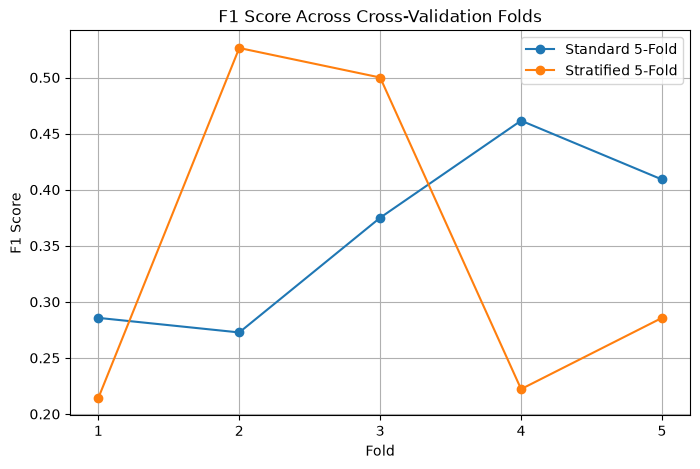

In [10]:
import matplotlib.pyplot as plt

folds = range(1, 6)

plt.figure(figsize=(8, 5))

plt.plot(
    folds,
    scores,
    marker="o",
    label="Standard 5-Fold"
)

plt.plot(
    folds,
    stratified_scores,
    marker="o",
    label="Stratified 5-Fold"
)

plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.title("F1 Score Across Cross-Validation Folds")
plt.xticks(folds)
plt.legend()
plt.grid(True)

plt.show()

## What does the comparison reveal?

The standard 5-fold cross-validation achieved a mean F1-score of
approximately 0.361 with a standard deviation of 0.072.

The stratified approach achieved a similar mean F1-score of approximately
0.350, but with a higher standard deviation of 0.136.

This indicates that the model's performance varies considerably across
the folds in the stratified evaluation. Therefore, the mean score alone
is not enough to describe model performance; the standard deviation also
helps us understand the stability of the model.

For this classification problem, stratification is still important
because it preserves the class distribution within each fold and makes
the evaluation process more appropriate for classification data.

## Final Takeaway

### What did we learn today?

A single validation split can give us a useful but potentially unstable
estimate of model performance. Cross-validation reduces this dependence
on one particular split by evaluating the model across multiple folds.

For our Decision Tree, the standard 5-fold cross-validation produced a
mean F1-score of 0.361 with a standard deviation of 0.072, while the
stratified approach produced a mean of 0.350 with a standard deviation
of 0.136.

The results also show why we should report both the mean and the
standard deviation. The mean describes the average performance, while
the standard deviation tells us how much that performance changes
between folds.

Since this is a classification problem, Stratified K-Fold is an
appropriate approach because it preserves the class distribution
across the folds.

Most importantly, cross-validation gives us a more reliable basis for
model comparison and tuning without repeatedly relying on a single
validation split.